# unstructured data analysis 

In [1]:
# importing libraries 

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import re 
import nltk 
from nltk.corpus import stopwords 
from nltk.stem import WordNetLemmatizer 

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [3]:
data=pd.read_csv("imbd.csv")

In [4]:
data


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [7]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [9]:
data.shape

(50000, 2)

In [10]:
data.describe

<bound method NDFrame.describe of                                                   review sentiment
0      One of the other reviewers has mentioned that ...  positive
1      A wonderful little production. <br /><br />The...  positive
2      I thought this was a wonderful way to spend ti...  positive
3      Basically there's a family where a little boy ...  negative
4      Petter Mattei's "Love in the Time of Money" is...  positive
...                                                  ...       ...
49995  I thought this movie did a down right good job...  positive
49996  Bad plot, bad dialogue, bad acting, idiotic di...  negative
49997  I am a Catholic taught in parochial elementary...  negative
49998  I'm going to have to disagree with the previou...  negative
49999  No one expects the Star Trek movies to be high...  negative

[50000 rows x 2 columns]>

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [12]:
#data cleaning 

In [13]:
data.isnull().sum()

review       0
sentiment    0
dtype: int64

In [14]:
data.duplicated().sum()

np.int64(418)

In [15]:
data.drop_duplicates(inplace=True)

In [16]:
data

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [17]:
# target distribution 

In [19]:
data['sentiment'].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

In [20]:
# target variable to numeric conversion 

In [21]:
data['sentiment']=data['sentiment'].map({'positive':1,'negative':0})

In [22]:
data

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1
...,...,...
49995,I thought this movie did a down right good job...,1
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",0
49997,I am a Catholic taught in parochial elementary...,0
49998,I'm going to have to disagree with the previou...,0


In [23]:
# text cleaning 

In [24]:
data['review']=data['review'].str.lower()

In [25]:
# remvoing html tags

In [11]:
def remove_html(text):
    return re.sub(r'<,*?>',  ' ',text)
data['review']=data['review'].apply(remove_html)

In [12]:
data

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [6]:
# in nlp - natural langauge processing , stopword and lemmitization are two types of techquines which are used to preprocess the text data 

In [8]:
#stopwords in nltk - very comman words "the","is","and","a" often nltk provides
#builtin stiopword lists for multiple lanagauges thta helps in reudcing 
#noise and improve nlp performance 
# basically nltk that are use to analyse the text data and for nlp

#lemmitization:
it converts the word to their dictionary base form (lemma) 
running - run 
dogs- dog
better-good 
unlike stemming , it priduces valid dictionary words they are acucrate 

In [13]:
#removing special characters 

In [14]:
def remove_special(text):
    return re.sub(r'[^a-zA-Z\s]', '',text)
data['review']=data['review'].apply(remove_special)

In [20]:
remove_special("i thought this mvie did a good job ")

'i thought this mvie did a good job '

In [21]:
# remove stopwords

In [23]:
nltk.download('stopwords')
stop_words=set(stopwords.words('english'))
def remove_stopwords(text):
    words=text.split()
    words=[word for word in words if word not in stop_words]
    return " ".join(words)
data['review']=data['review'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [24]:
# lemmiziation 

In [27]:
nltk.download('wordnet')
nltk.download('omw-1.4')
lemmatizer=WordNetLemmatizer()
def lemmatizer_text(text):
    words=text.split()
    words=[lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)
data['review']=data['review'].apply(lemmatizer_text)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [28]:
# eda

In [30]:
#dataset overview

In [31]:
print(data.shape)
print(data.info())
print(data.describe())

(50000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None
                                                   review sentiment
count                                               50000     50000
unique                                              49578         2
top     Loved today show It variety solely cooking wou...  positive
freq                                                    5     25000


In [32]:
#sentiment distribution 

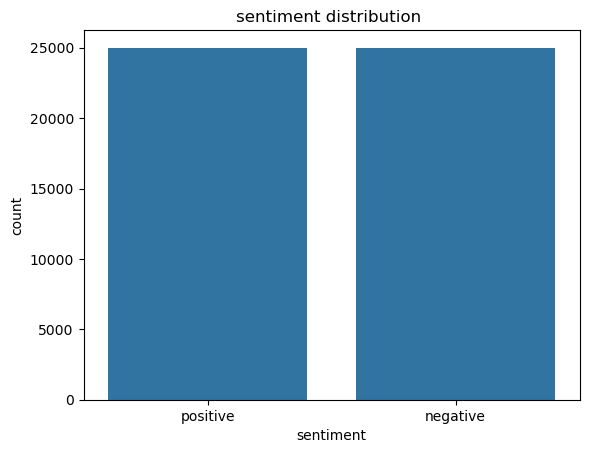

In [33]:
sns.countplot(x='sentiment',data=data)
plt.title("sentiment distribution ")
plt.show()

In [34]:
# plot the diagram for review lenght ")

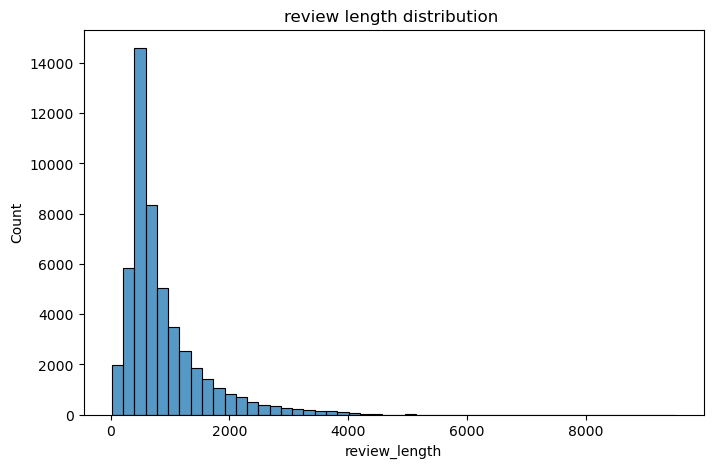

In [35]:
data['review_length']=data['review'].apply(len)
plt.figure(figsize=(8,5))
sns.histplot(data['review_length'],bins=50)
plt.title("review length distribution ")
plt.show()

In [36]:
# review length by statemnts

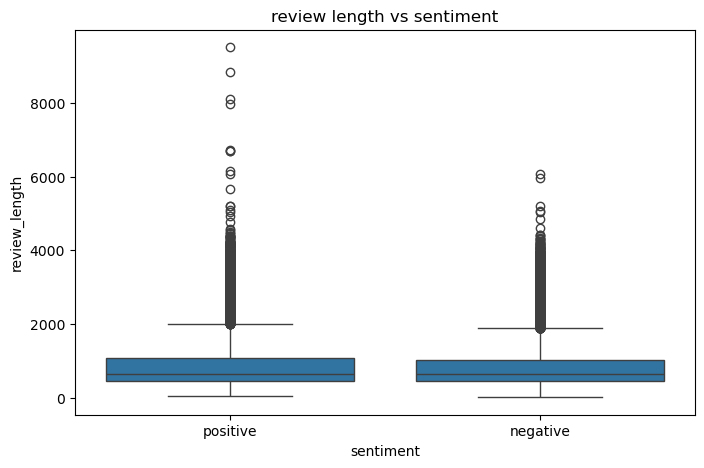

In [37]:
plt.figure(figsize=(8,5))
sns.boxplot(x='sentiment',y='review_length',data=data)
plt.title("review length vs sentiment")
plt.show()

In [38]:
#visuals 

In [39]:
#most frequent words 

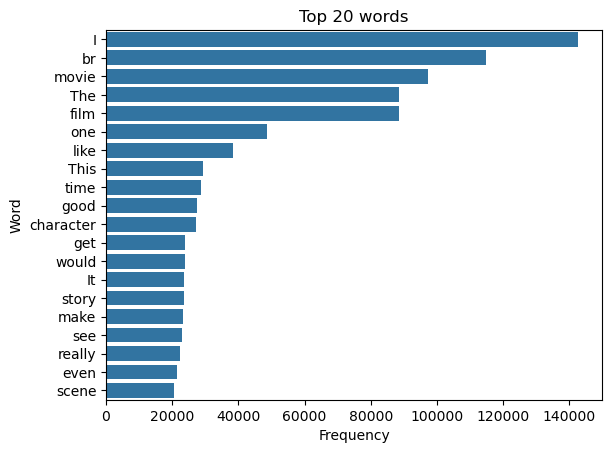

In [49]:
from collections import Counter 
all_words=" ".join(data['review']).split()
word_freq=Counter(all_words)
common_words=pd.DataFrame(
    word_freq.most_common(20),
    columns=['Word','Frequency']
)

sns.barplot(
    x='Frequency',
    y='Word',
    data=common_words
)
plt.title("Top 20 words")
plt.show()

In [50]:
# word cloud 


In [51]:
# install a libary in python 

In [52]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


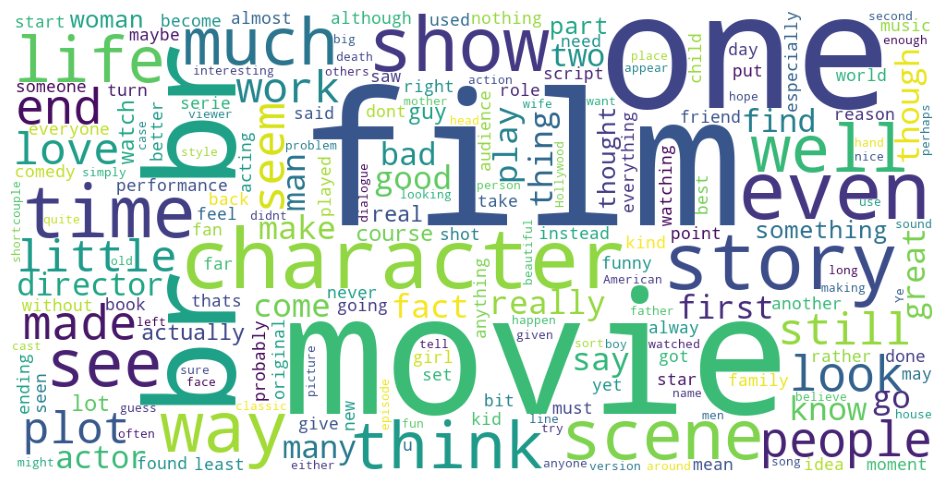

In [54]:
from wordcloud import WordCloud

text= " ".join(data['review'])
wc=WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis('off')
plt.show()

In [59]:
data

,review,sentiment,review_length
0,One reviewer mentioned watching Oz episode you...,positive,1182
1,A wonderful little production br br The filmin...,positive,681
2,I thought wonderful way spend time hot summer ...,positive,615
3,Basically there family little boy Jake think t...,negative,477
4,Petter Matteis Love Time Money visually stunni...,positive,895
...,...,...,...
49995,I thought movie right good job It wasnt creati...,positive,561
49996,Bad plot bad dialogue bad acting idiotic direc...,negative,427
49997,I Catholic taught parochial elementary school ...,negative,843
49998,Im going disagree previous comment side Maltin...,negative,834


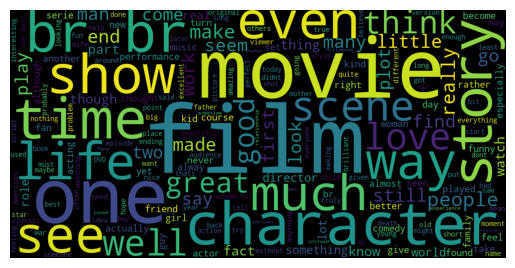

In [61]:
# positive word cloud 
positive_text=" ".join(
    data[data['sentiment']=='positive']['review']
)
WordCloud(
    width=1000,
    height=500
).generate(positive_text)

plt.imshow(
    WordCloud(width=1000,height=500)
    .generate(positive_text)
)
plt.axis('off')
plt.show()
    

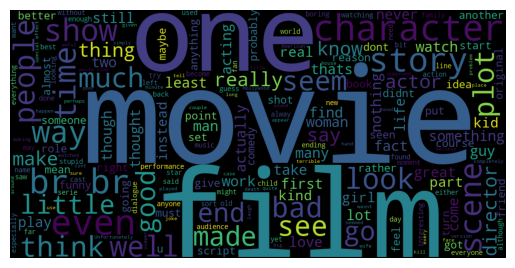

In [63]:
# negative word cloud 
negative_text=" ".join(
    data[data['sentiment']=='negative']['review']
)

plt.imshow(
    WordCloud(width=1000,height=500)
    .generate(negative_text)
)
plt.axis('off')
plt.show()
    

In [64]:
data['sentiment']=data['sentiment'].map({'positive':1,'negative':0})

In [65]:
data

,review,sentiment,review_length
0,One reviewer mentioned watching Oz episode you...,1,1182
1,A wonderful little production br br The filmin...,1,681
2,I thought wonderful way spend time hot summer ...,1,615
3,Basically there family little boy Jake think t...,0,477
4,Petter Matteis Love Time Money visually stunni...,1,895
...,...,...,...
49995,I thought movie right good job It wasnt creati...,1,561
49996,Bad plot bad dialogue bad acting idiotic direc...,0,427
49997,I Catholic taught parochial elementary school ...,0,843
49998,Im going disagree previous comment side Maltin...,0,834


In [66]:
# machine learning 

In [67]:
# TF-IDF VECTORIZATION 

In [68]:
# tf-idf is used in text data or unstrucutred data to trnaform the data 

In [71]:
X=data['review']
y=data['sentiment']

tfidf=TfidfVectorizer(
    max_features=5000
)
x=tfidf.fit_transform(X)

In [73]:
X

0        One reviewer mentioned watching Oz episode you...
1        A wonderful little production br br The filmin...
2        I thought wonderful way spend time hot summer ...
3        Basically there family little boy Jake think t...
4        Petter Matteis Love Time Money visually stunni...
                               ...                        
49995    I thought movie right good job It wasnt creati...
49996    Bad plot bad dialogue bad acting idiotic direc...
49997    I Catholic taught parochial elementary school ...
49998    Im going disagree previous comment side Maltin...
49999    No one expects Star Trek movie high art fan ex...
Name: review, Length: 50000, dtype: object

In [74]:
y

0        1
1        1
2        1
3        0
4        1
        ..
49995    1
49996    0
49997    0
49998    0
49999    0
Name: sentiment, Length: 50000, dtype: int64

In [75]:
# train test split

In [83]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    )

In [84]:
X_test

33553    I really liked Summerslam due look arena curta...
9427     Not many television show appeal quite many dif...
199      The film quickly get major chase scene ever in...
12447    Jane Austen would definitely approve onebr br ...
39489    Expectations somewhat high I went see movie I ...
                               ...                        
28567    Although Casper van Dien Michael Rooker genera...
25079    I liked movie I wasnt really sure I started wa...
18707    Yes nonSingaporeans cant see whats big deal fi...
15200    As far film go likable enough Entertaining cha...
5857     I saw Anatomy year ago dubbed friend house I d...
Name: review, Length: 10000, dtype: object

In [85]:
y_test

33553    1
9427     1
199      0
12447    1
39489    0
        ..
28567    0
25079    1
18707    1
15200    0
5857     1
Name: sentiment, Length: 10000, dtype: int64

In [86]:
X_train

39087    Thats I kept asking many fight screaming match...
30893    I watch entire movie I could watch entire movi...
45278    A touching love story reminiscent In Mood Love...
16398    This latterday Fulci schlocker totally abysmal...
13653    First I firmly believe Norwegian movie continu...
                               ...                        
11284    Shadow Magic recapture joy amazement first mov...
44732    I found movie quite enjoyable fairly entertain...
38158    Avoid one It terrible movie So exciting All po...
860      This production quite surprise I absolutely lo...
15795    This decent movie Although little bit short ti...
Name: review, Length: 40000, dtype: object

In [88]:
data

,review,sentiment,review_length
0,One reviewer mentioned watching Oz episode you...,1,1182
1,A wonderful little production br br The filmin...,1,681
2,I thought wonderful way spend time hot summer ...,1,615
3,Basically there family little boy Jake think t...,0,477
4,Petter Matteis Love Time Money visually stunni...,1,895
...,...,...,...
49995,I thought movie right good job It wasnt creati...,1,561
49996,Bad plot bad dialogue bad acting idiotic direc...,0,427
49997,I Catholic taught parochial elementary school ...,0,843
49998,Im going disagree previous comment side Maltin...,0,834


In [90]:
print(data['sentiment'].unique())

[1 0]


In [92]:
X=data['review']
y=data['sentiment']

tfidf =TfidfVectorizer(max_features=5000)
X=tfidf.fit_transform(X)

X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [93]:
# import logitsic regression

In [94]:
from sklearn.linear_model import LogisticRegression

In [95]:
#create the model

In [96]:
lr=LogisticRegression(max_iter=1000)


In [97]:
#train the model

In [98]:
lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [99]:
#make predictions

In [100]:
lr_pred=lr.predict(X_test)

In [102]:
lr_pred

array([0, 1, 0, ..., 1, 0, 1], shape=(10000,))

In [103]:
# accuracy 

In [104]:
# clasification model / logistic regression - confusion matrix

In [107]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test,lr_pred))

Accuracy: 0.8874


In [108]:
# classification report

In [111]:
from sklearn.metrics import classification_report
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [112]:
# confusion matrix

In [113]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,lr_pred)
print(cm)

[[4335  626]
 [ 500 4539]]


In [114]:
# confusion matrix you have four things - false positive , false negative , true positve and true negative 
# false positve - the actual you wished is not correct but you think its correct 
#flase negative - actual is not true and you think its not true 
#true positive - actual and predicted are both correct
#true negative - one is correct other is not 

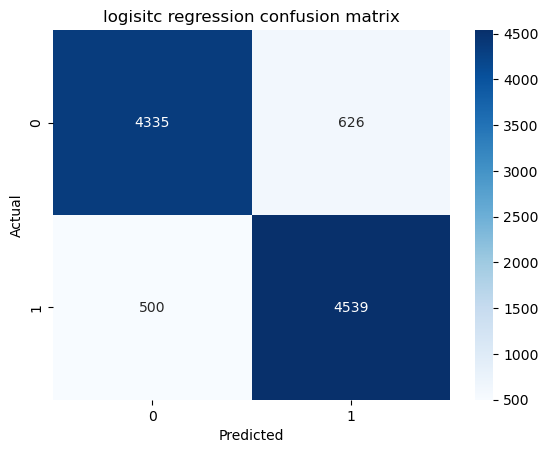

In [115]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("logisitc regression confusion matrix")
plt.show()

In [116]:
# lambda function 

In [117]:
# a lambda function is a function which is written in single line

In [118]:
# convert sentiments using lambda

In [119]:
data['sentiment']=data['sentiment'].apply(lambda x:1 if x=='positive' else 0)

In [120]:
data

,review,sentiment,review_length
0,One reviewer mentioned watching Oz episode you...,0,1182
1,A wonderful little production br br The filmin...,0,681
2,I thought wonderful way spend time hot summer ...,0,615
3,Basically there family little boy Jake think t...,0,477
4,Petter Matteis Love Time Money visually stunni...,0,895
...,...,...,...
49995,I thought movie right good job It wasnt creati...,0,561
49996,Bad plot bad dialogue bad acting idiotic direc...,0,427
49997,I Catholic taught parochial elementary school ...,0,843
49998,Im going disagree previous comment side Maltin...,0,834
